# VAE Portfolio Project - VAE Training

This notebook trains the Variational Autoencoder on portfolio returns.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import umap
from data_loader import PortfolioDataLoader, create_train_test_split
from vae_model import VAE, VAETrainer
from utils import PortfolioConfig, normalize_data

plt.rcParams['figure.figsize'] = (12, 6)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


## 1. Load and Prepare Data

In [2]:
config = PortfolioConfig()

# reload the data if the cached csv does not match the configured tickers
import os
returns_path = '../data/returns.csv'
prices_path = '../data/prices.csv'

if os.path.exists(returns_path):
    returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)
    if list(returns.columns) != config.indices:
        print('Existing returns.csv does not match the 60-asset configuration. Refreshing data from Yahoo Finance...')
        loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
        prices = loader.fetch_data()
        returns = loader.calculate_returns(method='log')
        prices.to_csv(prices_path, index=True)
        returns.to_csv(returns_path, index=True)
else:
    print('No cached returns found. Fetching data from Yahoo Finance...')
    loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
    prices = loader.fetch_data()
    returns = loader.calculate_returns(method='log')
    prices.to_csv(prices_path, index=True)
    returns.to_csv(returns_path, index=True)

print(f"Returns shape: {returns.shape}")

Existing returns.csv does not match the 60-asset configuration. Refreshing data from Yahoo Finance...
Returns shape: (4448, 60)


In [3]:
returns_normalized, scaler = normalize_data(returns.values, fit=True)
print(f"Mean: {returns_normalized.mean():.6f}")
print(f"Std: {returns_normalized.std():.6f}")

Mean: 0.000000
Std: 1.000000


In [4]:
# chronological split: train / validation / test
X_train, X_test = create_train_test_split(returns_normalized, test_size=0.2)
X_train_split, X_val = create_train_test_split(X_train, test_size=0.2)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (2846, 60)
Validation set: (712, 60)
Test set: (890, 60)


## 2. Initialize VAE Model

In [5]:
input_dim = X_train_split.shape[1]
latent_dim = config.latent_dim
hidden_dim = config.hidden_dim

vae = VAE(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim)
print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=128, out_features=18, bias=True)
  (logvar): Linear(in_features=128, out_features=18, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=60, bias=True)
  )
)


## 3. Train VAE

In [6]:
trainer = VAETrainer(
    model=vae,
    device=device,
    learning_rate=config.learning_rate,
    beta=1.0
)

trainer.train(
    X_train=X_train_split,
    X_val=X_val,
    n_epochs=config.n_epochs,
    batch_size=config.batch_size
)

Epoch 1/120 | Train Loss: 0.9716 | Val Loss: 0.9498
Epoch 10/120 | Train Loss: 0.5984 | Val Loss: 0.6960
Epoch 20/120 | Train Loss: 0.5550 | Val Loss: 0.6504
Epoch 30/120 | Train Loss: 0.5428 | Val Loss: 0.6421
Epoch 40/120 | Train Loss: 0.5364 | Val Loss: 0.6379
Epoch 50/120 | Train Loss: 0.5314 | Val Loss: 0.6341
Epoch 60/120 | Train Loss: 0.5281 | Val Loss: 0.6438
Epoch 70/120 | Train Loss: 0.5212 | Val Loss: 0.6434
Epoch 80/120 | Train Loss: 0.5192 | Val Loss: 0.6364
Epoch 90/120 | Train Loss: 0.5174 | Val Loss: 0.6312
Epoch 100/120 | Train Loss: 0.5144 | Val Loss: 0.6418
Epoch 110/120 | Train Loss: 0.5122 | Val Loss: 0.6380
Epoch 120/120 | Train Loss: 0.5099 | Val Loss: 0.6402


## 4. Plot Training History

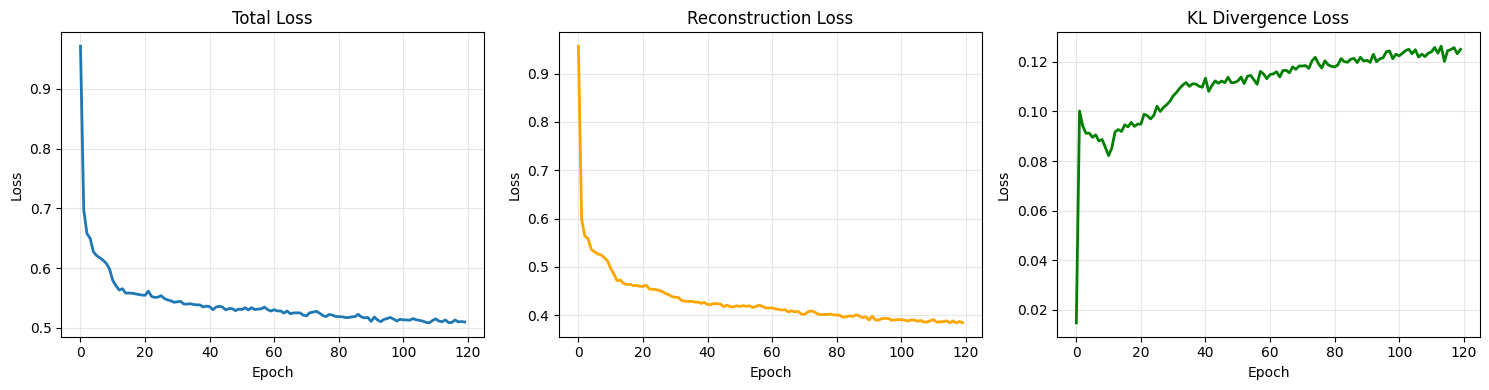

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(trainer.history['total_loss'], linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(trainer.history['recon_loss'], linewidth=2, color='orange')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(trainer.history['kl_loss'], linewidth=2, color='green')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/04_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Evaluate on Test Set

In [8]:
vae.eval()
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    recon_x, mu, logvar, z = vae(X_test_tensor)
    recon_loss = ((recon_x - X_test_tensor) ** 2).mean().item()

print(f"Test Reconstruction Loss: {recon_loss:.6f}")
print(f"Latent space shape: {z.shape}")

Test Reconstruction Loss: 0.496740
Latent space shape: torch.Size([890, 18])


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


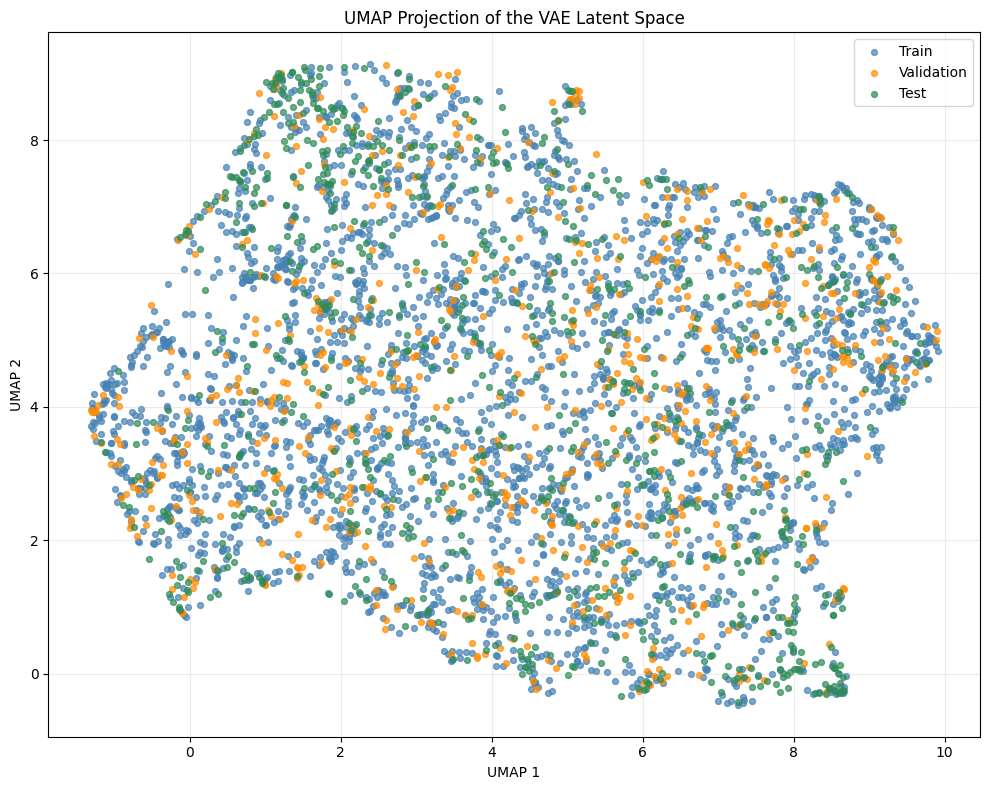

In [9]:
# 2D UMAP projection of the latent means
vae.eval()
X_train_tensor = torch.FloatTensor(X_train_split).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    train_mu, _ = vae.encode(X_train_tensor)
    val_mu, _ = vae.encode(X_val_tensor)
    test_mu, _ = vae.encode(X_test_tensor)

latent_train = train_mu.cpu().numpy()
latent_val = val_mu.cpu().numpy()
latent_test = test_mu.cpu().numpy()
latent_all = np.vstack([latent_train, latent_val, latent_test])
latent_labels = (
    ['Train'] * len(latent_train)
    + ['Validation'] * len(latent_val)
    + ['Test'] * len(latent_test)
)

reducer = umap.UMAP(n_neighbors=20, min_dist=0.15, metric='euclidean', random_state=42)
latent_umap = reducer.fit_transform(latent_all)

fig, ax = plt.subplots(figsize=(10, 8))
label_colors = {'Train': 'steelblue', 'Validation': 'darkorange', 'Test': 'seagreen'}
for label in ['Train', 'Validation', 'Test']:
    mask = np.array(latent_labels) == label
    ax.scatter(
        latent_umap[mask, 0],
        latent_umap[mask, 1],
        s=18,
        alpha=0.7,
        label=label,
        color=label_colors[label],
    )

ax.set_title('UMAP Projection of the VAE Latent Space')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('../results/05_latent_space_umap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Save Model

In [10]:
torch.save({
    'model_state': vae.state_dict(),
    'config': config,
    'scaler': scaler
}, '../results/vae_model.pth')

print("Model saved to ../results/vae_model.pth")

Model saved to ../results/vae_model.pth
